# Problem Statement :
The objective of this project is to perform Exploratory Data Analysis (EDA) on a Credit Risk dataset to identify the key factors affecting loan status and understand customer credit behavior through statistical analysis and visualizations.

In [42]:
# Step 1. Import libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [43]:
# Step 2. Load Dataset
df = pd.read_csv(r"C:\Users\mohit\Innomatics\Credit_risk_Analysis_EDA\credit_risk_dataset.csv")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [44]:
# step - 3. Display Dataset (head, tail, sample)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [45]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [46]:
# Step - 4. Check Shape
df.shape

(32581, 12)

#### Observations :
- The dataset contains 32,581 rows.
- The dataset contains 12 columns.
- Since the dataset has a large number of records, it is suitable for exploratory analysis and predictive modeling.

# Checking Datatypes, Null values, and memory usage

In [47]:
# step - 5. Check Data Types (info)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [48]:
# step - 6. Statistical Summary (describe)
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Data Cleaning :
1. Missing values
2. Duplicates
3. Outliers
4. Type Casting
5. Noisy or inconsistent data

# Check Missing Values

In [49]:
# step - 7. Missing Value Analysis
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

<Axes: >

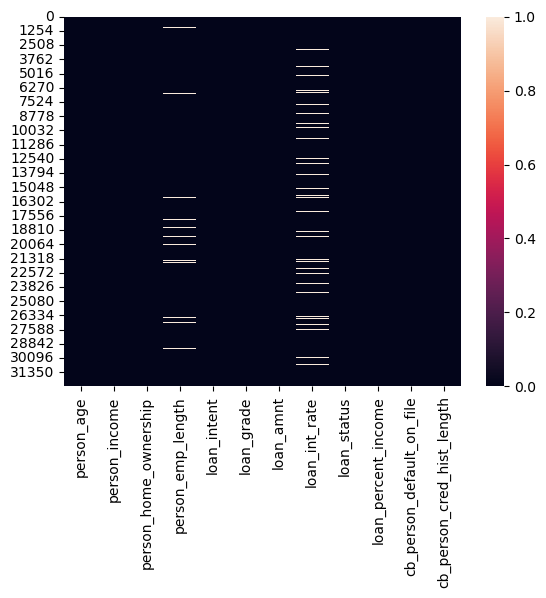

In [50]:
sns.heatmap(df.isnull())

In [51]:
round((df.isnull().sum()/df.shape[0]) * 100,2)

person_age                    0.00
person_income                 0.00
person_home_ownership         0.00
person_emp_length             2.75
loan_intent                   0.00
loan_grade                    0.00
loan_amnt                     0.00
loan_int_rate                 9.56
loan_status                   0.00
loan_percent_income           0.00
cb_person_default_on_file     0.00
cb_person_cred_hist_length    0.00
dtype: float64

#### Observation:
Person_emp_length and loan_int_rate have missing values 
>- Person_emp_length - 895 missing values
>- loan_int_rate - 3116 missing values
All other columns have no missing values.

Since missing values exist, 
they must be handled before further analysis.

# Handling Missing values

In [52]:
# steop - 8. Handle Missing Values
df['person_emp_length'] = df["person_emp_length"].fillna(df["person_emp_length"].median())
df['loan_int_rate'] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())

In [53]:
# Rechecking
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

#### Observation :
- Median is used because these variables may contain outliers.
- Missing values are successfully handled.
- The dataset becomes cleaner and suitable for further analysis.

# Detecting Duplicate values

In [54]:
# step - 9. Duplicate Check
df.duplicated().sum()

np.int64(165)

#### Observation : 
There are 165 Duplicate values in the dataset

# Handling Duplicate values

In [55]:
df.drop_duplicates(inplace = True)

In [56]:
# Rechecking

In [57]:
df.duplicated().sum()

np.int64(0)

# Observation : 
- Duplicate records increase bias in analysis.
- If duplicates are found, they should be removed.
- After removal, each record represents a unique observation.

# Noisy or inconsistent data

In [58]:
# step - 10. Unique Values
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [59]:
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

In [60]:
# Step - 11. Remove Unnecessary Column

# Observations : 
- There are no Noisy and inconsistent data in the dataset 
- There is no unique columns like id so we don't want to remove any columns

# Relpace columns values to easy graphs 

In [61]:
#To make graph eaiser and interpretation easier we can replace the loan_status and cb_person_default_on_file columns 

In [62]:
df["loan_status"] = df["loan_status"].replace({0: "Approved", 1: "Not Approved"})
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].replace({"Y": "Yes", "N": "No"})

In [63]:
# rechecking
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,Not Approved,0.59,Yes,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,Approved,0.10,No,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,Not Approved,0.57,No,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,Not Approved,0.53,No,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,Not Approved,0.55,Yes,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,Approved,0.11,No,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,Approved,0.15,No,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,Not Approved,0.46,No,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,Approved,0.10,No,26


In [64]:
df.shape

(32416, 12)

# Detecting and Handling Outlier

In [65]:
# step - 12. Univariate Analysis (11 graphs)
num_cols = df.select_dtypes(include='number')
cat_cols = df.select_dtypes(include="object")

In [66]:
cat_cols.head()

,person_home_ownership,loan_intent,loan_grade,loan_status,cb_person_default_on_file
0,RENT,PERSONAL,D,Not Approved,Yes
1,OWN,EDUCATION,B,Approved,No
2,MORTGAGE,MEDICAL,C,Not Approved,No
3,RENT,MEDICAL,C,Not Approved,No
4,RENT,MEDICAL,C,Not Approved,Yes


In [67]:
num_cols.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,35000,16.02,0.59,3
1,21,9600,5.0,1000,11.14,0.10,2
2,25,9600,1.0,5500,12.87,0.57,3
3,23,65500,4.0,35000,15.23,0.53,2
4,24,54400,8.0,35000,14.27,0.55,4


In [68]:
num_cols.skew()

person_age                     2.580490
person_income                 32.958748
person_emp_length              2.668217
loan_amnt                      1.191944
loan_int_rate                  0.220183
loan_percent_income            1.063811
cb_person_cred_hist_length     1.659369
dtype: float64

In [69]:
df.groupby('loan_grade')['loan_amnt'].agg(['mean','max','min'])

,mean,max,min
loan_grade,,,
A,8545.702140,35000,500
B,9992.228266,35000,500
C,9219.175210,35000,500
D,10855.759669,35000,1000
E,12919.911734,35000,1000
F,14717.323651,35000,1200
G,17195.703125,35000,1600


In [70]:
df.groupby(
    ['loan_grade','loan_status']
).size()

loan_grade  loan_status 
A           Approved        9637
            Not Approved    1066
B           Approved        8692
            Not Approved    1695
C           Approved        5102
            Not Approved    1336
D           Approved        1482
            Not Approved    2138
E           Approved         342
            Not Approved     621
F           Approved          71
            Not Approved     170
G           Approved           1
            Not Approved      63
dtype: int64

In [71]:
df.groupby('loan_intent')['loan_int_rate'].mean()

loan_intent
DEBTCONSOLIDATION    10.989632
EDUCATION            10.957958
HOMEIMPROVEMENT      11.189900
MEDICAL              11.057009
PERSONAL             11.002734
VENTURE              10.957168
Name: loan_int_rate, dtype: float64

### Detecting outliers using boxplot

<Axes: xlabel='person_age'>

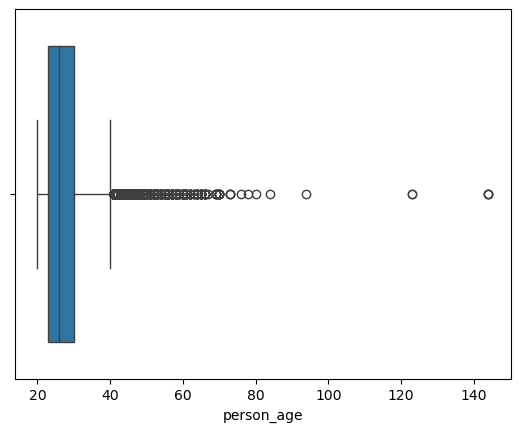

In [72]:
sns.boxplot(data=df, x='person_age')

<Axes: >

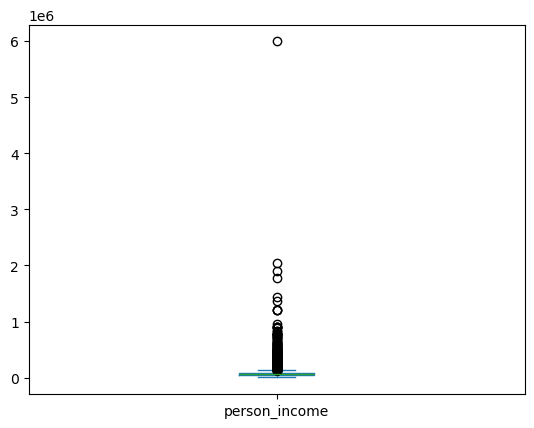

In [73]:
df['person_income'].plot(kind = 'box')

<Axes: xlabel='person_emp_length'>

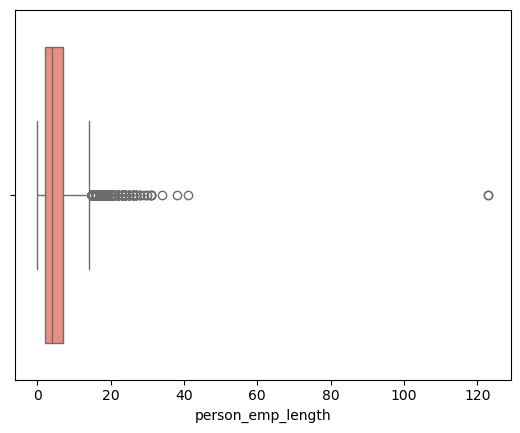

In [74]:
sns.boxplot(data=df, x='person_emp_length', color='salmon')

<Axes: ylabel='loan_amnt'>

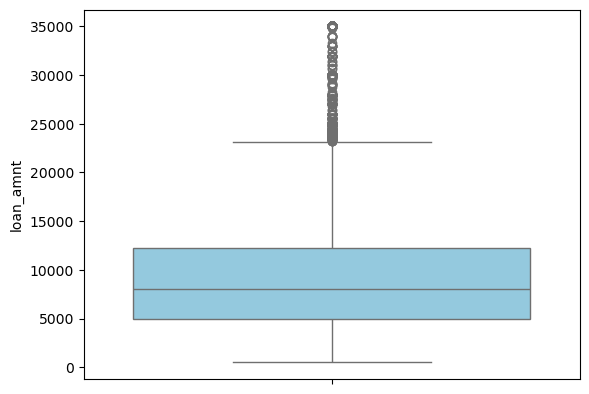

In [75]:
sns.boxplot(data=df, y='loan_amnt', color='skyblue')

<Axes: ylabel='loan_int_rate'>

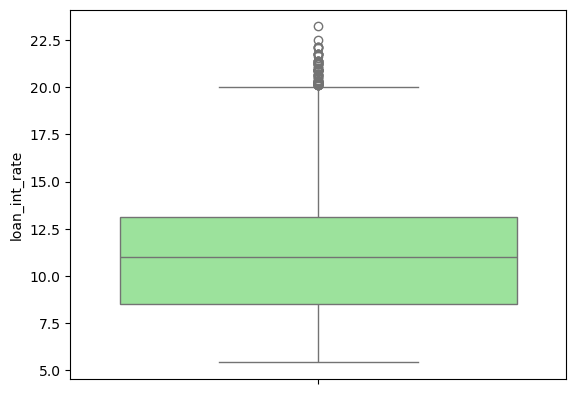

In [76]:
sns.boxplot(data=df, y='loan_int_rate', color='lightgreen')

<Axes: ylabel='loan_percent_income'>

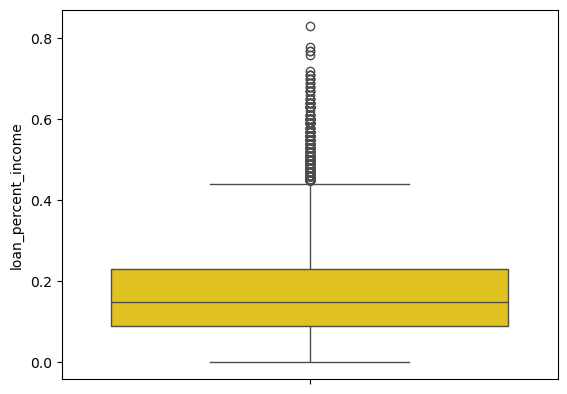

In [77]:
sns.boxplot(data=df, y='loan_percent_income', color='gold')

<Axes: ylabel='cb_person_cred_hist_length'>

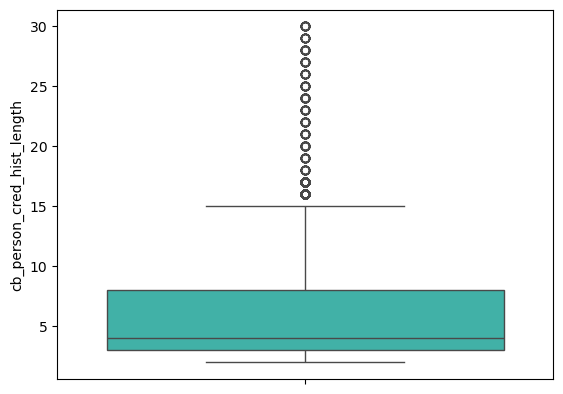

In [78]:
sns.boxplot(data=df, y='cb_person_cred_hist_length', color='#2ec4b6')  

## Observation :
Since variables such as person_income, loan_amnt, and loan_int_rate represent actual financial characteristics, extremely high values may correspond to genuine customers rather than errors. Therefore, these columns are excluded from outlier detection and handling to preserve meaningful business information.

# Detecting outliers uisng IQR Method

In [79]:
Q1 = df['person_age'].quantile(0.25)
Q3 = df['person_age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['person_age'] < lower) | (df['person_age'] > upper)]

print('Total Outliers in person_age column :', outliers.shape[0])

Total Outliers in person_age column : 1491


## Explanation : 
Outlier handling was applied selectively rather than uniformly. Financial variables such as **`person_income`**, **`loan_amnt`**, and **`loan_int_rate`** were not treated for outliers because extreme values may represent genuine high-income individuals or large loan transactions. Removing these observations could result in the loss of valuable business information. Only variables with potentially unrealistic values, such as **`person_age`** (and **`person_emp_length`** if necessary), were considered for outlier detection and handling.

# Handling the Outliers

In [80]:
Q1 = df['person_age'].quantile(0.25)
Q3 = df['person_age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['person_age'] >= lower) & (df['person_age'] <= upper)]

# Observation :
- The number of rows decreases after removing outliers.
- The number of columns remains unchanged.
- Only records with unrealistic age values are removed.

# Average Income by Home Ownership

In [81]:
df.groupby('loan_grade')['loan_amnt'].agg(['mean','max','min'])

,mean,max,min
loan_grade,,,
A,8535.076818,35000,500
B,9950.781093,35000,500
C,9229.896529,35000,500
D,10808.788892,35000,1000
E,12775.842391,35000,1000
F,14677.323009,35000,1200
G,17024.596774,35000,1600


## Observation
- Shows the average income for each home ownership category.
- Helps understand the financial profile of different customer groups.

# Average Loan Amount by Loan Grade

In [82]:
df.groupby('loan_grade')['loan_amnt'].mean()

loan_grade
A     8535.076818
B     9950.781093
C     9229.896529
D    10808.788892
E    12775.842391
F    14677.323009
G    17024.596774
Name: loan_amnt, dtype: float64

# Observation
- Displays the average loan amount across loan grades.
- Helps compare borrowing patterns among different credit grades.

# Average Interest Rate by Loan Intent

In [83]:
df.groupby('loan_intent')['loan_int_rate'].mean()

loan_intent
DEBTCONSOLIDATION    10.983421
EDUCATION            10.951998
HOMEIMPROVEMENT      11.185480
MEDICAL              11.052109
PERSONAL             11.015552
VENTURE              10.958071
Name: loan_int_rate, dtype: float64

# Observation
- Shows the average interest rate for each loan purpose.
- Helps identify which loan purposes are associated with higher interest rates.

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30925 entries, 0 to 32296
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  30925 non-null  int64  
 1   person_income               30925 non-null  int64  
 2   person_home_ownership       30925 non-null  object 
 3   person_emp_length           30925 non-null  float64
 4   loan_intent                 30925 non-null  object 
 5   loan_grade                  30925 non-null  object 
 6   loan_amnt                   30925 non-null  int64  
 7   loan_int_rate               30925 non-null  float64
 8   loan_status                 30925 non-null  object 
 9   loan_percent_income         30925 non-null  float64
 10  cb_person_default_on_file   30925 non-null  object 
 11  cb_person_cred_hist_length  30925 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 3.1+ MB


# Data Visualization

# Univariate analysis

## 1. Age Distribution

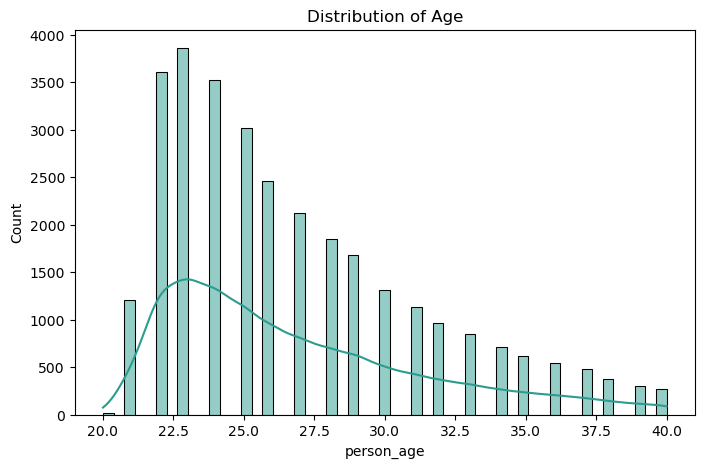

In [85]:
plt.figure(figsize=(8,5))
sns.histplot(df['person_age'], kde=True,  color = '#2a9d8f')
plt.title("Distribution of Age")
plt.show()

# Observation :
- Shows the distribution of customer ages.
- Most applicants are expected to be concentrated in the young and middle-age groups.
- Any extreme ages may indicate outliers.

# 2. Income Distribution

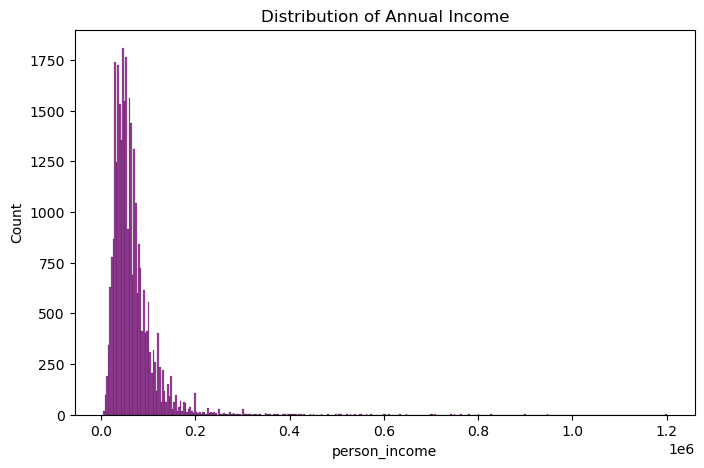

In [86]:
plt.figure(figsize=(8,5))
sns.histplot(df['person_income'], color = 'purple')
plt.title("Distribution of Annual Income")
plt.show()

# Observation :
- Displays income distribution.
- Income is often right-skewed because a few customers have very high incomes.

# 3.  loan Amount Distribution

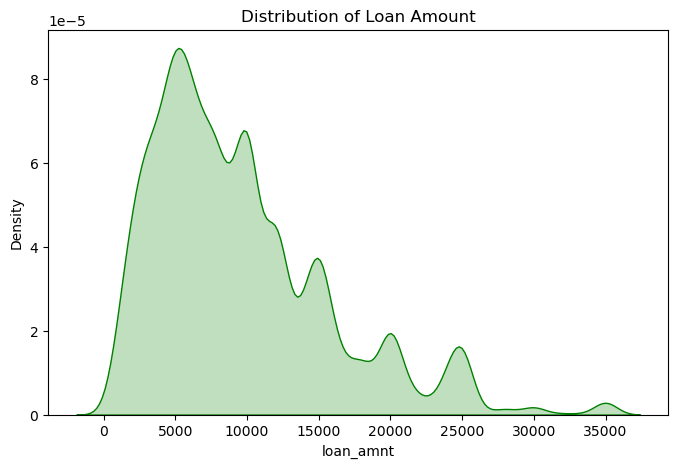

In [117]:
plt.figure(figsize=(8,5))
sns.kdeplot(x = 'loan_amnt', data = df, fill = True, color = 'green')
plt.title("Distribution of Loan Amount")
plt.show()

# Observation :
- Helps understand the distribution of loan amounts.
- Most customers typically apply for moderate loan amounts.

# 4. Interest Rate Distribution

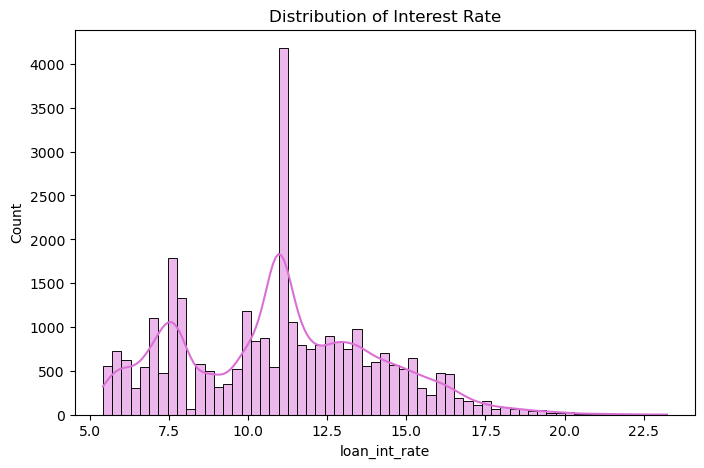

In [118]:
plt.figure(figsize = (8,5))
sns.histplot(df['loan_int_rate'], kde=True, color = 'orchid')
plt.title('Distribution of Interest Rate')
plt.show()

# Purpose
To observe interest rate patterns.

# 5. Home Ownership

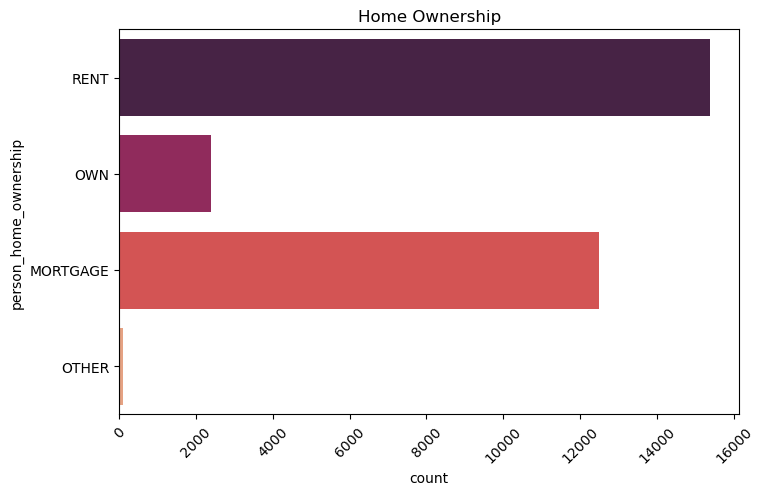

In [119]:
plt.figure(figsize=(8,5))
sns.countplot(y = 'person_home_ownership', data = df, palette = 'rocket')
plt.xticks(rotation=45)
plt.title("Home Ownership")
plt.show()

# Observation :
- The graph shows the frequency of each home ownership category.
- One category (such as RENT or MORTGAGE) is likely to have the highest number of applicants.
- Other categories have comparatively fewer observations.

# 6. Loan Purpose

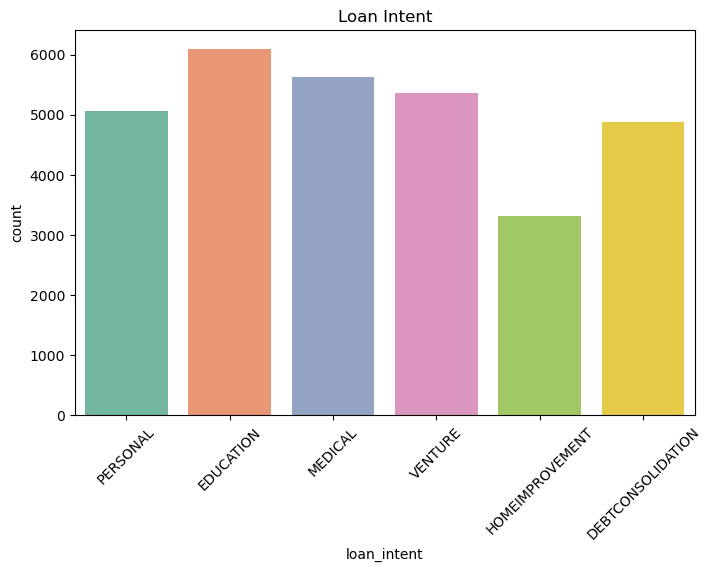

In [120]:
plt.figure(figsize=(8,5))
sns.countplot(x='loan_intent', data=df, palette = 'Set2')
plt.xticks(rotation=45)
plt.title("Loan Intent")
plt.show()

# Observation :
- The count plot displays the distribution of different loan purposes.
- Certain loan purposes (such as Education or Personal) may have the highest frequency.
- Some categories are relatively less common among applicants.

# 7. Loan Status

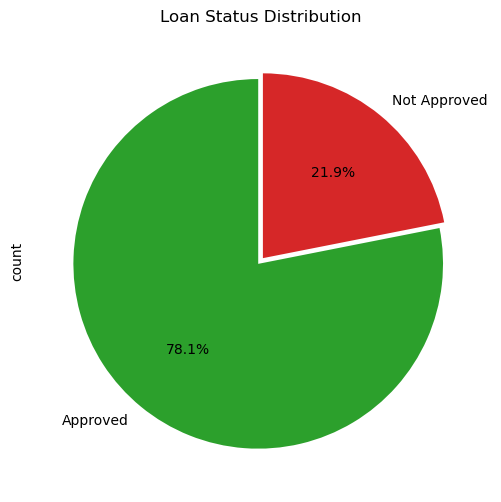

In [129]:
plt.figure(figsize=(6,6))
custom_colors = ['#2ca02c', '#d62728']
df['loan_status'].value_counts().plot(kind = 'pie',autopct = '%1.1f%%',
                                      startangle=90, explode = [0.02]*df['loan_status'].nunique(),
                                     colors=custom_colors)
plt.title('Loan Status Distribution')
plt.show()

# Observation :
- The pie chart shows the proportion of each loan status category.
- The majority of loans belong to one category (Approved/Non-Default), while the remaining belong to the other category.
- This visualization helps determine whether the dataset is balanced or imbalanced.

# Bivariate Analysis

# 1. Icome vs Loan Amount

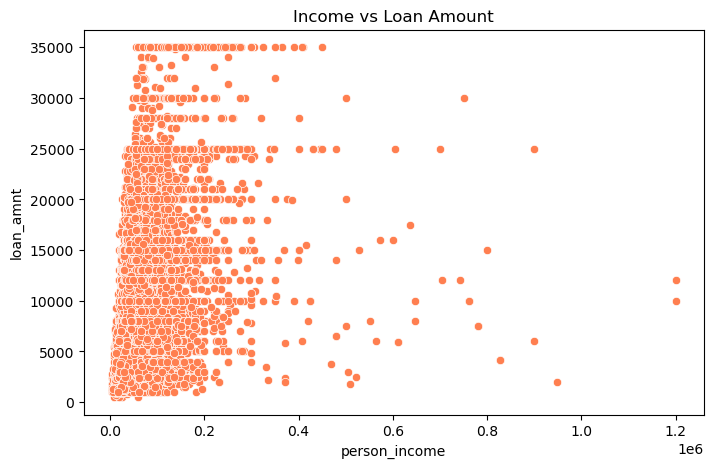

In [122]:
plt.figure(figsize=(8,5))
sns.scatterplot(x = 'person_income', y = 'loan_amnt', data = df, color = 'coral')
plt.title('Income vs Loan Amount')
plt.show()

# Observation
- Shows the relationship between income and loan amount.
- Higher-income customers may request larger loans.

# 2. Loan Grade vs Loan Status

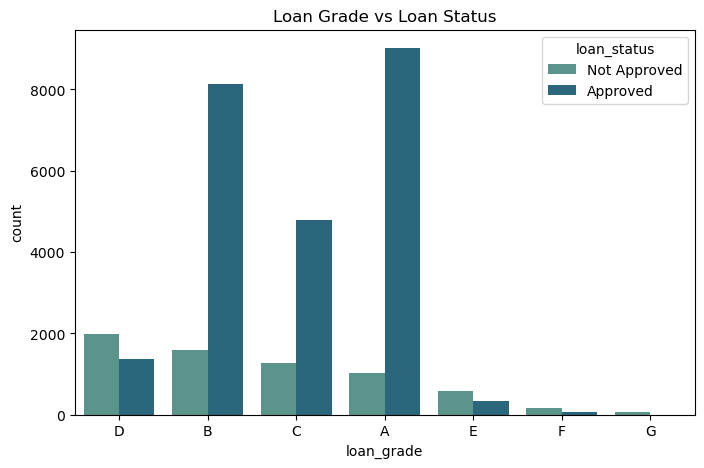

In [123]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'loan_grade', hue = 'loan_status', data = df, palette = 'crest')
plt.title('Loan Grade vs Loan Status')
plt.show()

# Observation
- Compares loan status across loan grades.
- Lower grades generally tend to have more defaults.

# 3. Home Ownership vs Loan Status

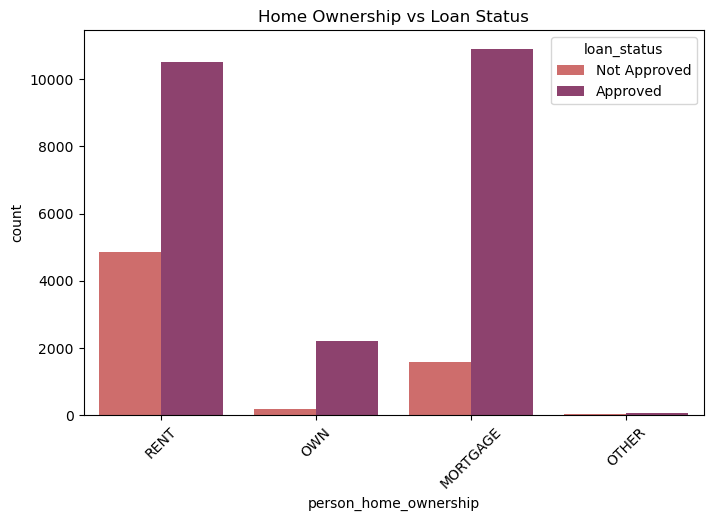

In [124]:
plt.figure(figsize = (8,5))
sns.countplot(x = 'person_home_ownership', hue = 'loan_status', data = df, palette = 'flare')
plt.xticks(rotation = 45)
plt.title('Home Ownership vs Loan Status')
plt.show()

# Observation
- Shows how loan status varies with home ownership.
- Some ownership categories may have higher approval or repayment rates.

# 4. Loan Intent vs Loan Status

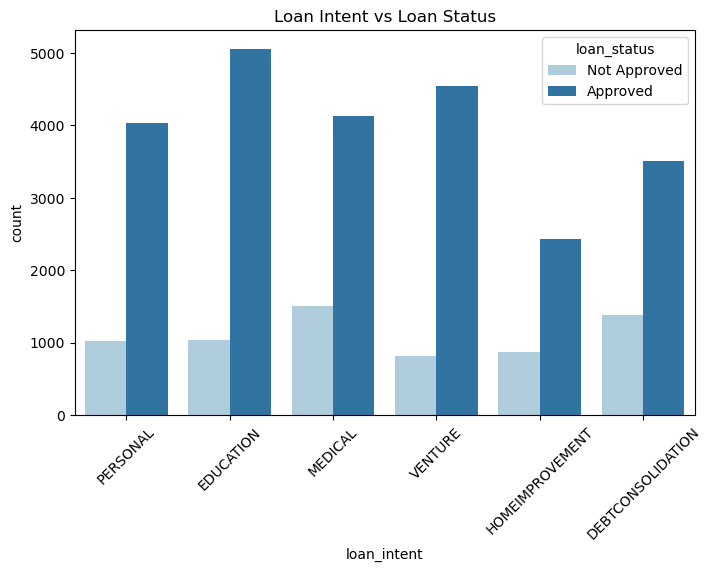

In [125]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'loan_intent',hue = 'loan_status', data = df, palette = 'Paired')
plt.xticks(rotation = 45)
plt.title('Loan Intent vs Loan Status')
plt.show()

# Observation:
Compares the distribution of interest rates for different loan status groups and highlights outliers.

# Multivariate Analysis

# 1. Correlation Analysis

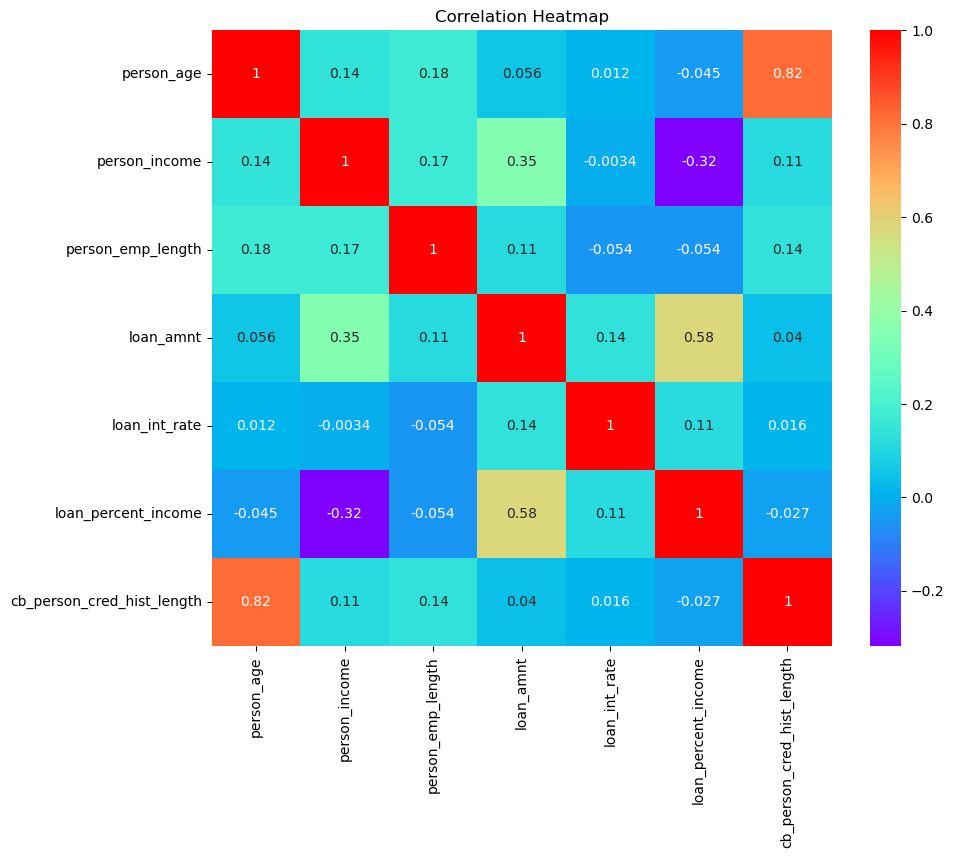

In [126]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'rainbow')
plt.title('Correlation Heatmap')
plt.show()

# Observation:
- Displays correlations among numerical variables.
- Helps identify positive and negative relationships and potential feature importance.

# 2. Pair Plot

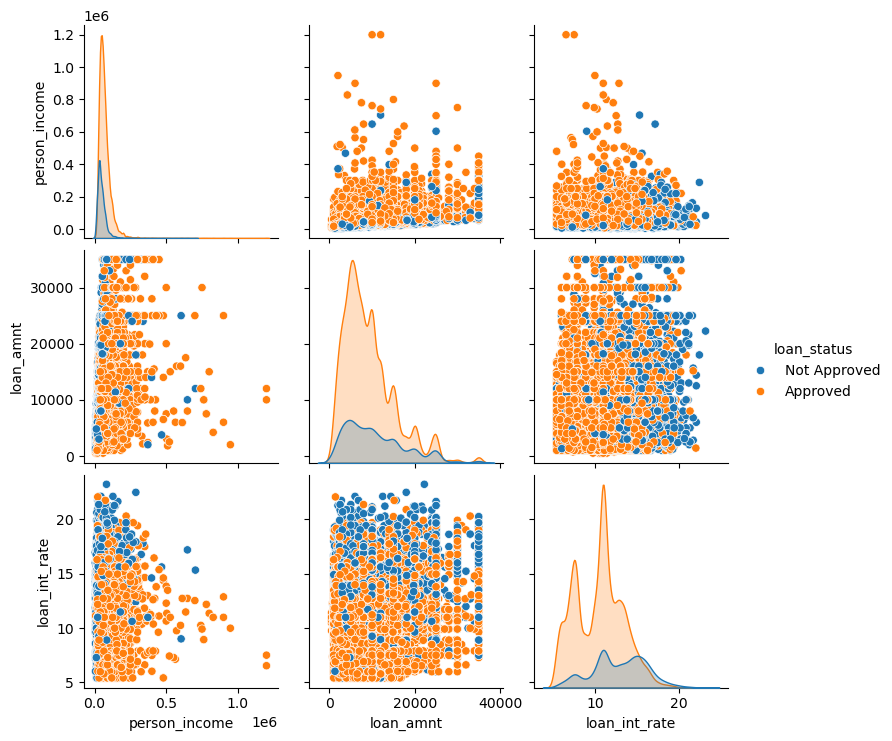

In [127]:
sns.pairplot(df[['person_income','loan_amnt','loan_int_rate','loan_status']], hue = 'loan_status')
plt.show()

# Observation 
- Examines relationships among multiple numerical variables.
- Different loan status groups can be visually compared across several feature combinations.

# 3. Scatter Plot

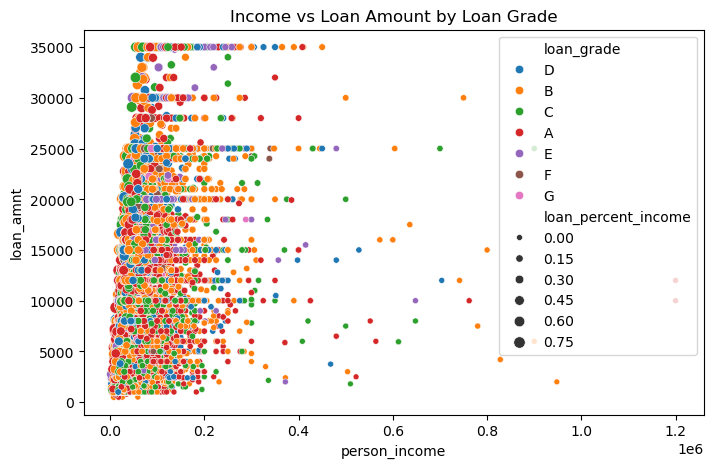

<Figure size 640x480 with 0 Axes>

In [128]:
plt.figure(figsize=(8,5))
sns.scatterplot(x = 'person_income', y = 'loan_amnt', hue = 'loan_grade', size = 'loan_percent_income', data = df)
plt.title("Income vs Loan Amount by Loan Grade")
plt.show()
plt.tight_layout()

# Observation
- Simultaneously analyzes income, loan amount, loan grade, and loan percent income.
- Reveals how multiple factors interact and helps identify patterns among different customer groups.

# Pivot Tables

In [131]:
pivot1 = pd.pivot_table(df, index='loan_grade', columns='loan_status', aggfunc='size', fill_value=0)
pivot1

loan_status,Approved,Not Approved
loan_grade,,
A,9022,1016
B,8135,1592
C,4782,1268
D,1378,1978
E,325,581
F,65,150
G,1,61


# Observation
- Shows the number of Approved/Not Approved (or Default/Non-Default) loans for each loan grade.
- Helps identify which grades have higher risk.
- Useful for understanding the relationship between credit grade and loan outcome.

In [132]:
pivot2 = pd.pivot_table(df, index='person_home_ownership', values='loan_amnt', aggfunc='mean')
pivot2

,loan_amnt
person_home_ownership,
MORTGAGE,10528.130006
OTHER,10935.824742
OWN,9043.255620
RENT,8841.184698


# Observation
- Displays the average loan amount for each home ownership type.
- Helps determine whether homeowners or renters generally borrow larger amounts.
- Useful for customer segmentation.

In [133]:
pivot3 = pd.pivot_table(df, index='loan_intent', values='loan_int_rate', aggfunc='mean')
pivot3

,loan_int_rate
loan_intent,
DEBTCONSOLIDATION,10.979127
EDUCATION,10.941902
HOMEIMPROVEMENT,11.183708
MEDICAL,11.051566
PERSONAL,11.014838
VENTURE,10.960897


# Observation
- Shows the average interest rate for each loan purpose.
- Some loan purposes may have higher average interest rates than others.
- Helps identify relatively riskier loan categories.